### About Columns :

**Diabetes_binary** :  Indicates if the respondent has diabetes (0 = No, 1 = Yes).

**HighBP** : Adults who have been diagnosed with high blood pressure by a healthcare professional (0 = No, 1 = Yes).

**HighChol** : Whether a healthcare provider has ever informed the respondent of having high cholesterol (0 = No, 1 = Yes).

**CholCheck** :Whether the respondent had a cholesterol check within the past five years (0 = No, 1 = Yes).

**BMI** : The respondent's Body Mass Index.

**Smoker** : Indicates if the respondent has ever smoked at least 100 cigarettes (equivalent to five packs) in their lifetime (0 = No, 1 = Yes).

**Stroke** : Whether the respondent has ever been diagnosed with a stroke (0 = No, 1 = Yes).

**HeartDiseaseorAttack** :  Indicates if the respondent has reported coronary heart disease or a heart attack in the past (0 = No, 1 = Yes).

**PhysActivity** : Whether the respondent engaged in physical activity or exercise, excluding work-related activities, in the past 30 days (0 = No, 1 = Yes).

**Fruits** : Frequency of consuming fruit at least once per day (0 = No, 1 = Yes).

**Veggies** : Frequency of consuming vegetables at least once per day (0 = No, 1 = Yes).

**HvyAlcoholConsump** : Indicates heavy alcohol consumption (men: more than 14 drinks per week, women: more than 7 drinks per week) (0 = No, 1 = Yes).

**AnyHealthcare** : Whether the respondent has any form of health insurance or coverage (0 = No, 1 = Yes).

**NoDocbcCost** : Whether there was a time in the past year when the respondent could not see a doctor due to cost (0 = No, 1 = Yes).

**GenHlth** : Self-assessed general health rating (1 = Excellent to 5 = Poor).

**MentHlth** : Number of days in the last 30 when the respondent's mental health was poor (range: 0 to 30 days).

**PhysHlth** : Number of days in the last 30 when the respondent's physical health was poor due to illness or injury (range: 0 to 30 days).

**DiffWalk** : Indicates if the respondent has serious difficulty walking or climbing stairs (0 = No, 1 = Yes).

**Sex** : The gender of the respondent (0 = Female, 1 = Male).

**Age** : Age grouped into fourteen categories (1 to 13).

**Education** : Highest level of education completed by the respondent (1 = Less than high school to 6 = Postgraduate degree).

**Income** : Annual household income, categorized into eight levels (1 = Lowest to 8 = Highest; refusals are coded as "Refused").

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


# read in the data
data = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# Data Exploring

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# split the data into train and test sets
X = data.drop('Diabetes_binary', axis=1)
y = data['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [3]:
data.shape

(253680, 22)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
data.head()


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


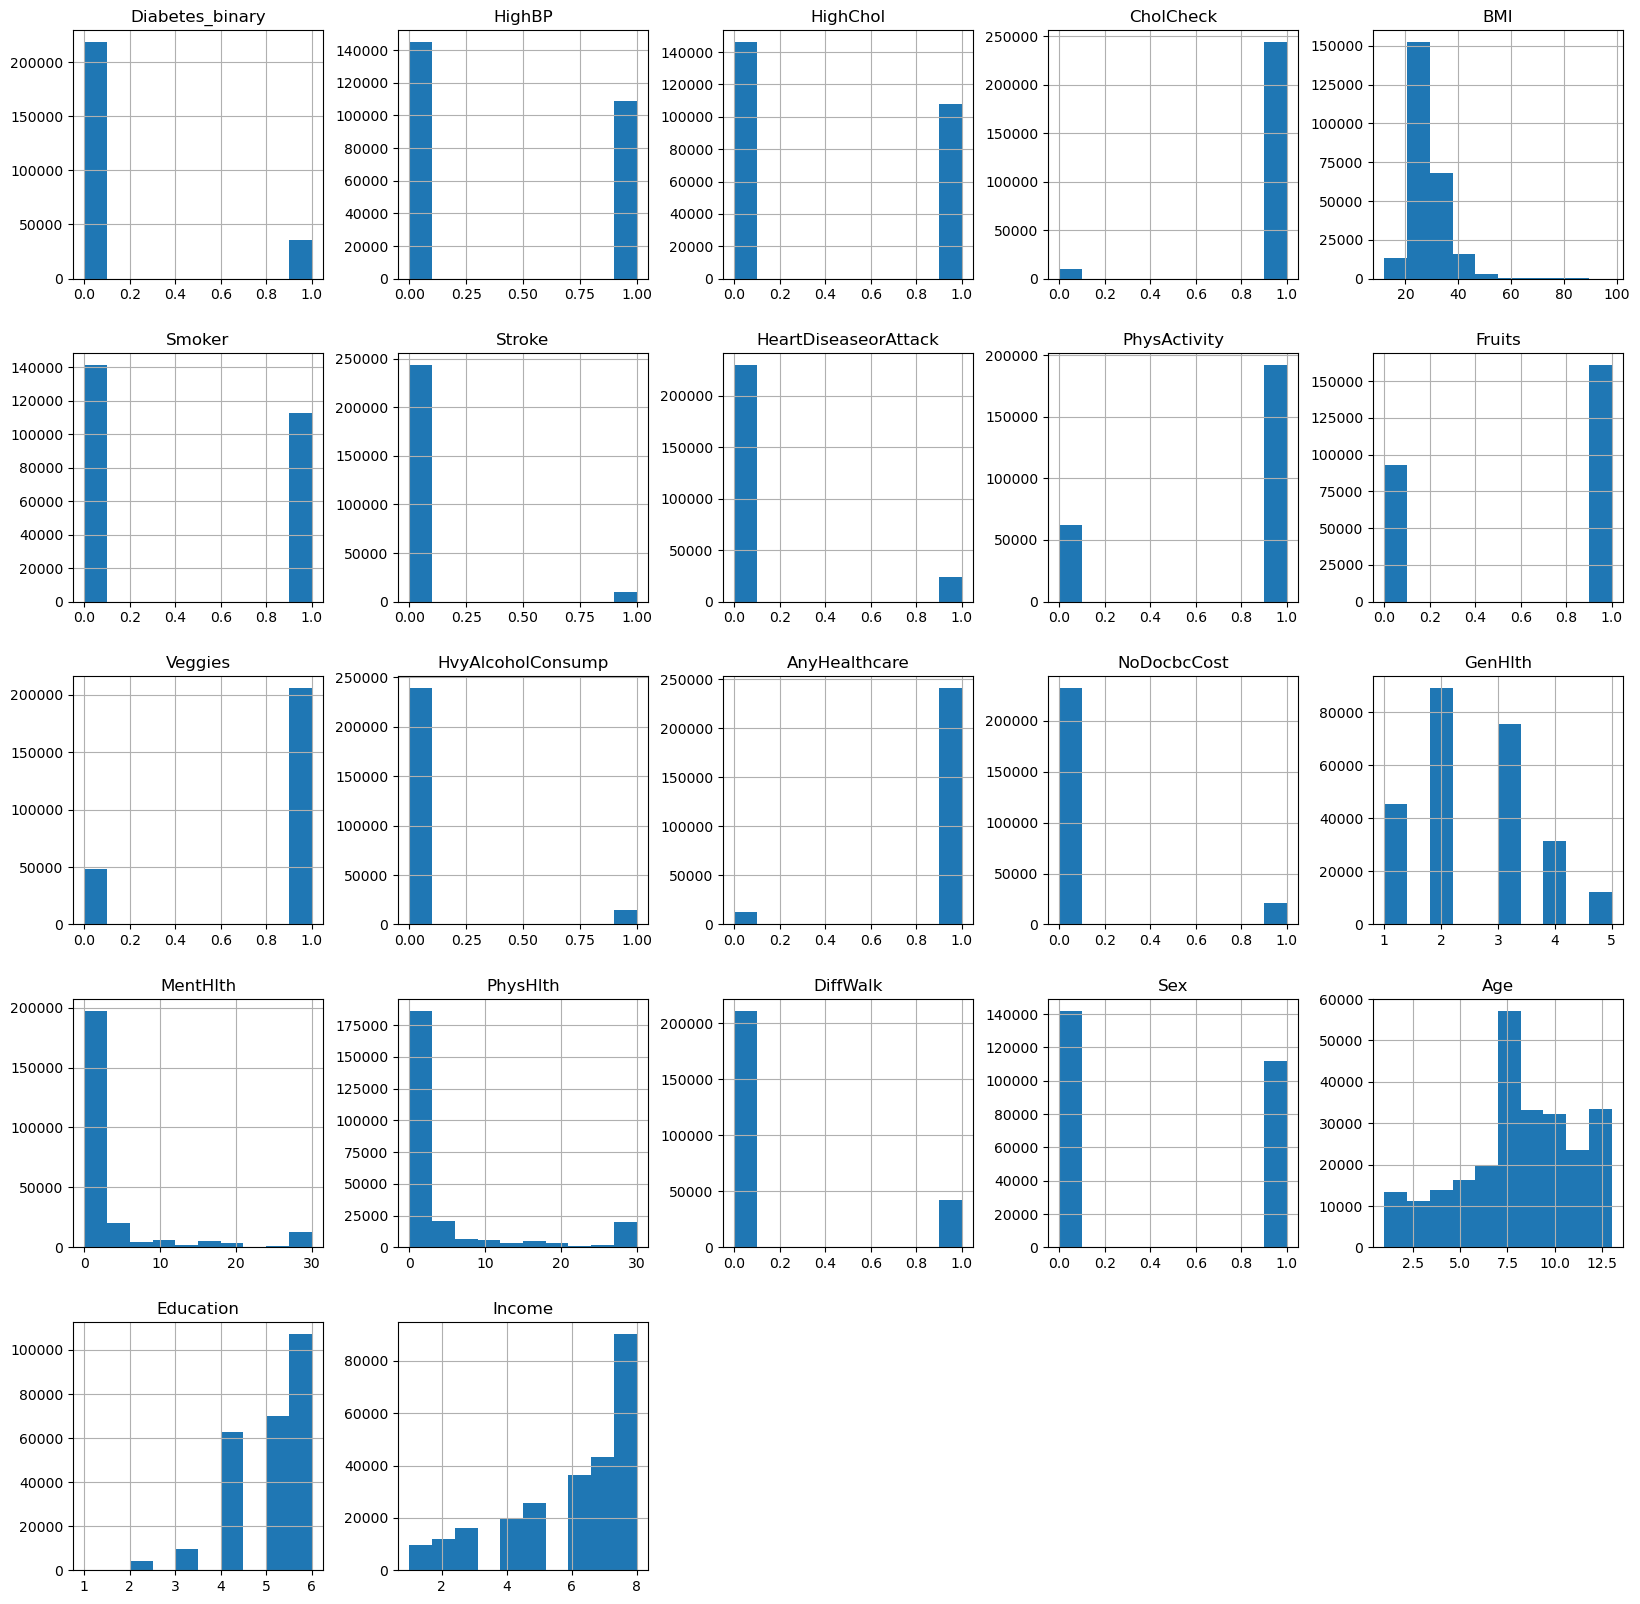

In [6]:
data.hist(figsize=(20,20));

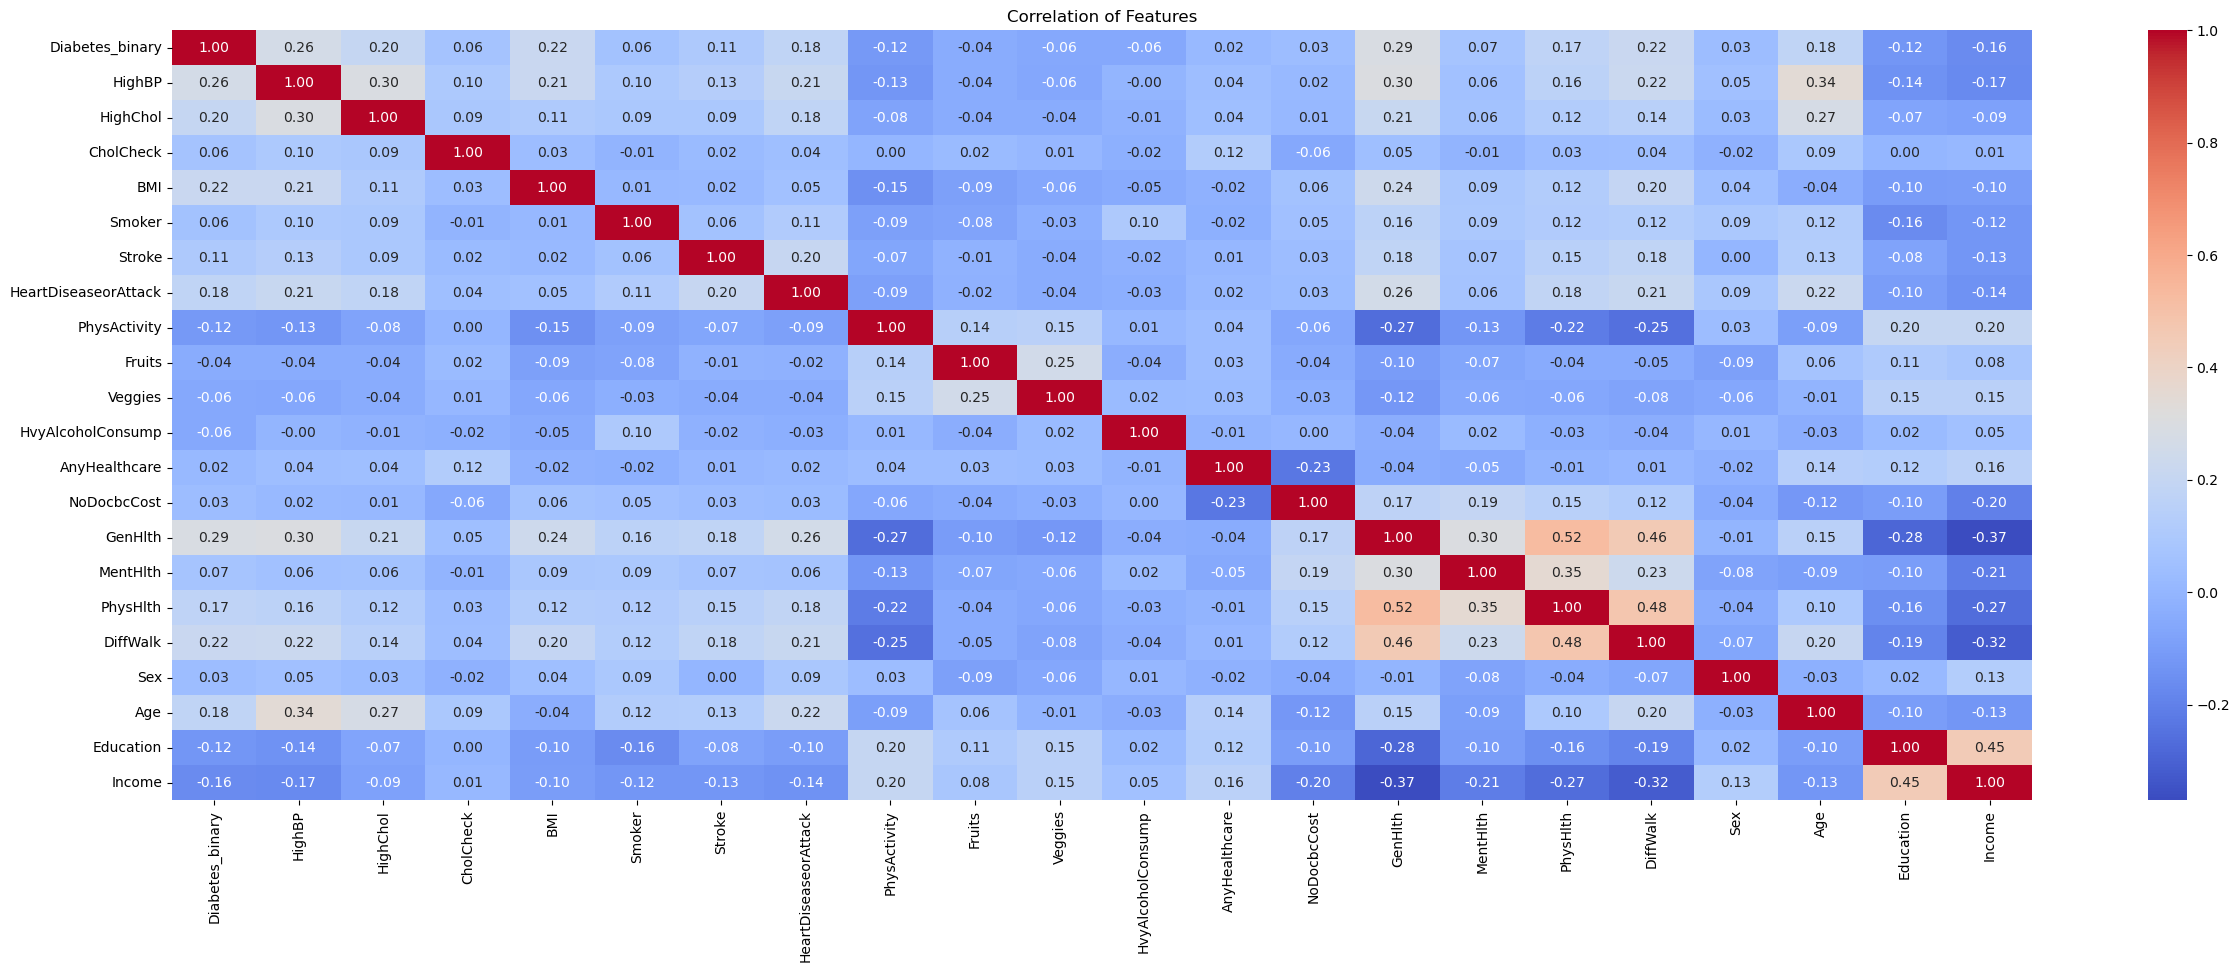

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation of Features")
plt.show()


In [8]:
data.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


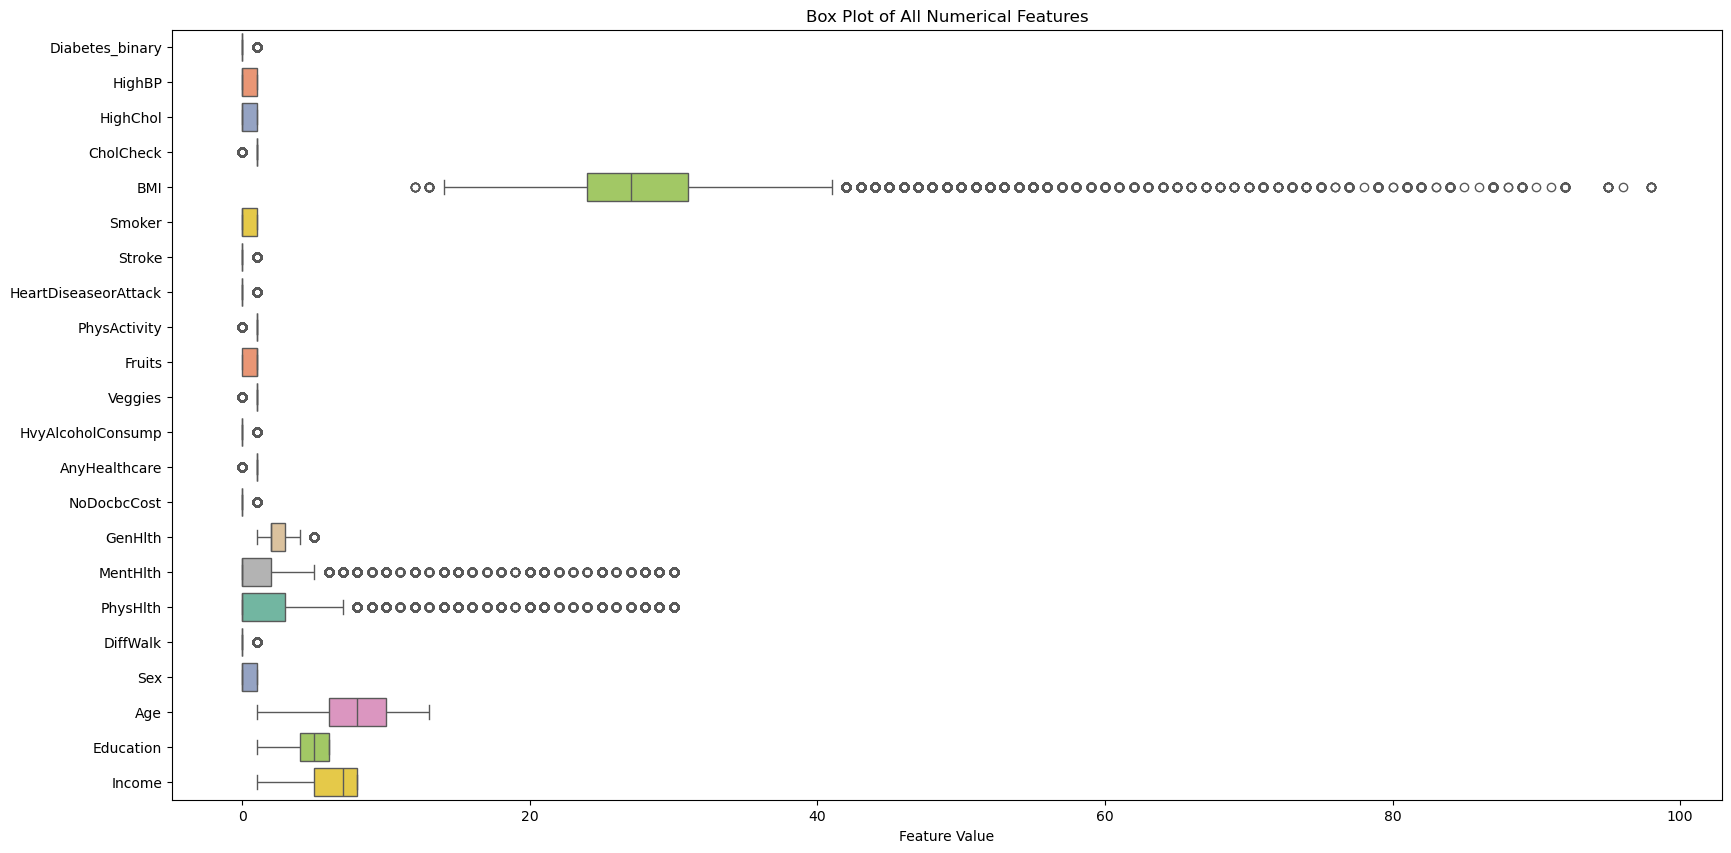

In [9]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=data.select_dtypes(include=['float64', 'int64']), orient='h', palette='Set2')
plt.title("Box Plot of All Numerical Features")
plt.xlabel("Feature Value")
plt.show()


In [10]:
# delete the columns that are not needed
data.drop_duplicates(inplace=True)

# change the target variable to binary
data = data.astype(int)

print(data['Diabetes_binary'].value_counts(normalize=True))


Diabetes_binary
0    0.847055
1    0.152945
Name: proportion, dtype: float64


# Preprocessing and Logistic Regression

In [11]:
# preprocessing
numeric_features = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('impute', SimpleImputer(strategy='mean')), ('scale', StandardScaler())]), numeric_features)
    ],
    remainder='passthrough'
)

# create a pipeline with preprocessing and logistic regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500, random_state=42, class_weight='balanced'))
])

# fit the model to the training set
model_pipeline.fit(X_train, y_train)

# make predictions
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

# evaluate the model
print("LogisticRegression classification report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

LogisticRegression classification report:
               precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

ROC AUC: 0.8196422342353251


# Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

brf = RandomForestClassifier(n_estimators=200, random_state=42)
brf.fit(X_train, y_train)

# predict
y_pred_brf = brf.predict(X_test)
y_prob_brf = brf.predict_proba(X_test)[:, 1]

# evaluate
print("Random Forest classification report:\n", classification_report(y_test, y_pred_brf))
print("Random Forest ROC AUC:", roc_auc_score(y_test, y_prob_brf))

Random Forest classification report:
               precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736

Random Forest ROC AUC: 0.7969206130283785


# Balanced Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# try random forest
rf_model = RandomForestClassifier(
max_depth=7,n_estimators=1000, class_weight='balanced', random_state=42)
# fit the model
rf_model.fit(X_train, y_train)

# drop unnecessary columns from X_test
X_test_rf = X_test.drop(columns=['Diabetes_Predicted'])

# make predictions
y_pred_rf = rf_model.predict(X_test_rf)
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]

# evaluate the model
print("Balanced Random Forest classification report:\n", classification_report(y_test, y_pred_rf))
print("Balanced Random Forest ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Balanced Random Forest classification report:
               precision    recall  f1-score   support

         0.0       0.95      0.71      0.81     43667
         1.0       0.30      0.78      0.43      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.74      0.62     50736
weighted avg       0.86      0.72      0.76     50736

Balanced Random Forest ROC AUC: 0.818156407508059


# Gradient Boosted Trees

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

# try gradient boosted trees
gb_model = GradientBoostingClassifier(
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=3,  
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosted Trees classification report:\n", classification_report(y_test, y_pred_gb))
print("Gradient Boosted Trees ROC AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosted Trees classification report:
               precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.55      0.17      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.57      0.59     50736
weighted avg       0.83      0.86      0.83     50736

Gradient Boosted Trees ROC AUC: 0.8264158551273975


# Improved Gradient Boosted Trees (Weight)

In [18]:
from sklearn.utils.class_weight import compute_sample_weight

# compute sample weights
sample_weights = compute_sample_weight(class_weight={0: 1, 1: 5}, y=y_train)

# fit the model with sample weights
gb_model_weighted = GradientBoostingClassifier(
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=3,  
    random_state=42
)

gb_model_weighted.fit(X_train, y_train, sample_weight=sample_weights)

# make predictions
y_pred_gb_weighted = gb_model_weighted.predict(X_test)
y_prob_gb_weighted = gb_model_weighted.predict_proba(X_test)[:, 1]

print("Gradient Boosted Trees classification report with weights:\n", classification_report(y_test, y_pred_gb_weighted))
print("Gradient Boosted Trees ROC AUC:", roc_auc_score(y_test, y_prob_gb_weighted))

Gradient Boosted Trees classification report with weights:
               precision    recall  f1-score   support

         0.0       0.95      0.76      0.84     43667
         1.0       0.33      0.73      0.46      7069

    accuracy                           0.75     50736
   macro avg       0.64      0.75      0.65     50736
weighted avg       0.86      0.75      0.79     50736

Gradient Boosted Trees ROC AUC: 0.8264463298531641


# XGboost 

In [19]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

for weight in [3, 4, 5, 6, 7]:
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        scale_pos_weight=weight,
        random_state=42
    )
    
    xgb_model.fit(X_train, y_train)
    
    y_pred = xgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:, 1]  

    print(f"\nscale_pos_weight={weight}")
    print("XGboost Classification Report:\n", classification_report(y_test, y_pred))
    print("XGboost ROC AUC:", roc_auc_score(y_test, y_prob))



scale_pos_weight=3
XGboost Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.87      0.89     43667
         1.0       0.40      0.55      0.46      7069

    accuracy                           0.82     50736
   macro avg       0.66      0.71      0.68     50736
weighted avg       0.85      0.82      0.83     50736

XGboost ROC AUC: 0.8238746397615776

scale_pos_weight=4
XGboost Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.81      0.87     43667
         1.0       0.36      0.66      0.46      7069

    accuracy                           0.79     50736
   macro avg       0.65      0.73      0.67     50736
weighted avg       0.86      0.79      0.81     50736

XGboost ROC AUC: 0.823911149824232

scale_pos_weight=5
XGboost Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.76      0.84     43667
         1

# Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

# Scale the training and test data
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

dt_model = DecisionTreeClassifier(
    max_depth=5,               
    class_weight='balanced',   
    random_state=42
)
dt_model.fit(X_train_scaled, y_train)

# predict
y_pred_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# 5. Evaluate the model
print("Decision Tree classification report:\n", classification_report(y_test, (y_pred_dt >= 0.5).astype(int)))
print("Decision Tree ROC AUC:", roc_auc_score(y_test, y_pred_dt))

Decision Tree classification report:
               precision    recall  f1-score   support

         0.0       0.95      0.69      0.80     43667
         1.0       0.28      0.77      0.42      7069

    accuracy                           0.70     50736
   macro avg       0.62      0.73      0.61     50736
weighted avg       0.86      0.70      0.74     50736

Decision Tree ROC AUC: 0.8011051699632019


# Selected Model: Gradient Boosted Trees with weights

In [21]:
# compute sample weights
sample_weights = compute_sample_weight(class_weight={0: 1, 1: 5}, y=y_train)

# fit the model with sample weights
gb_model_weighted = GradientBoostingClassifier(
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=3,  
    random_state=42
)

gb_model_weighted.fit(X_train, y_train, sample_weight=sample_weights)

# make predictions
y_pred_gb_weighted = gb_model_weighted.predict(X_test)
y_prob_gb_weighted = gb_model_weighted.predict_proba(X_test)[:, 1]

print("Gradient Boosted Trees classification report with weights:\n", classification_report(y_test, y_pred_gb_weighted))
print("Gradient Boosted Trees ROC AUC:", roc_auc_score(y_test, y_prob_gb_weighted))


Gradient Boosted Trees classification report with weights:
               precision    recall  f1-score   support

         0.0       0.95      0.76      0.84     43667
         1.0       0.33      0.73      0.46      7069

    accuracy                           0.75     50736
   macro avg       0.64      0.75      0.65     50736
weighted avg       0.86      0.75      0.79     50736

Gradient Boosted Trees ROC AUC: 0.8264463298531641


# Feature Selection

## 1. Feature Importance 

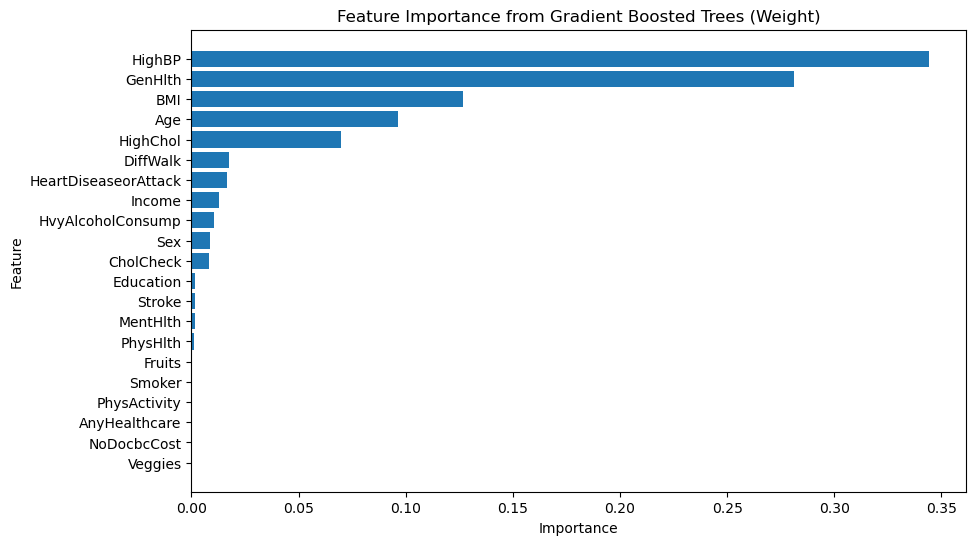

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model_weighted.feature_importances_
})

# sort the features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance from Gradient Boosted Trees (Weight)")
plt.gca().invert_yaxis()
plt.show()

## Top 10 by Feature Importance

Top Features Based on Importance:
                  Feature  Importance
0                 HighBP    0.344405
13               GenHlth    0.281223
3                    BMI    0.126620
18                   Age    0.096342
1               HighChol    0.069680
16              DiffWalk    0.017754
6   HeartDiseaseorAttack    0.016578
20                Income    0.012874
10     HvyAlcoholConsump    0.010385
17                   Sex    0.008548


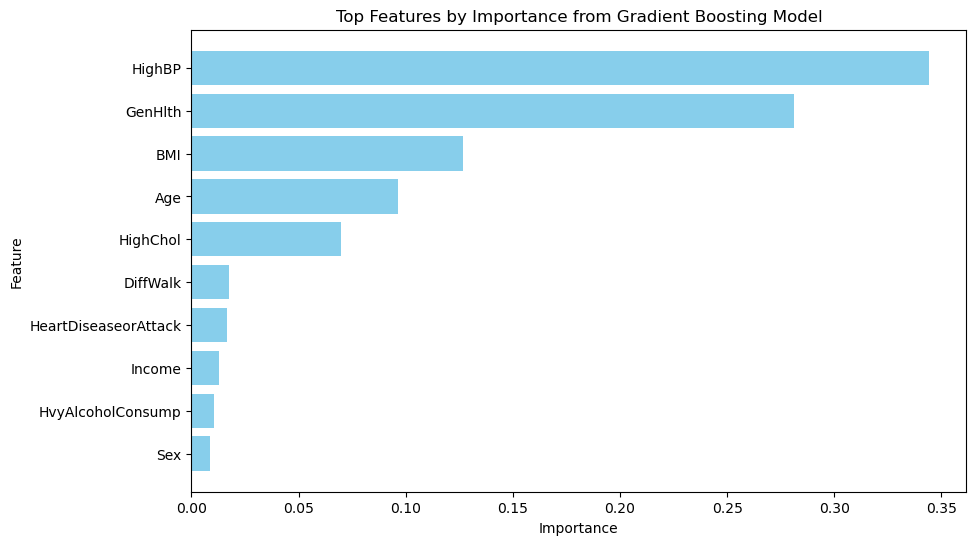

In [23]:
top_k = 10  
print("Top Features Based on Importance:\n", feature_importance.head(top_k))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'].head(top_k), feature_importance['Importance'].head(top_k), color='skyblue')
plt.gca().invert_yaxis()  
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Features by Importance from Gradient Boosting Model')
plt.show()


## Correlation Matrix of Top 10 Key Features

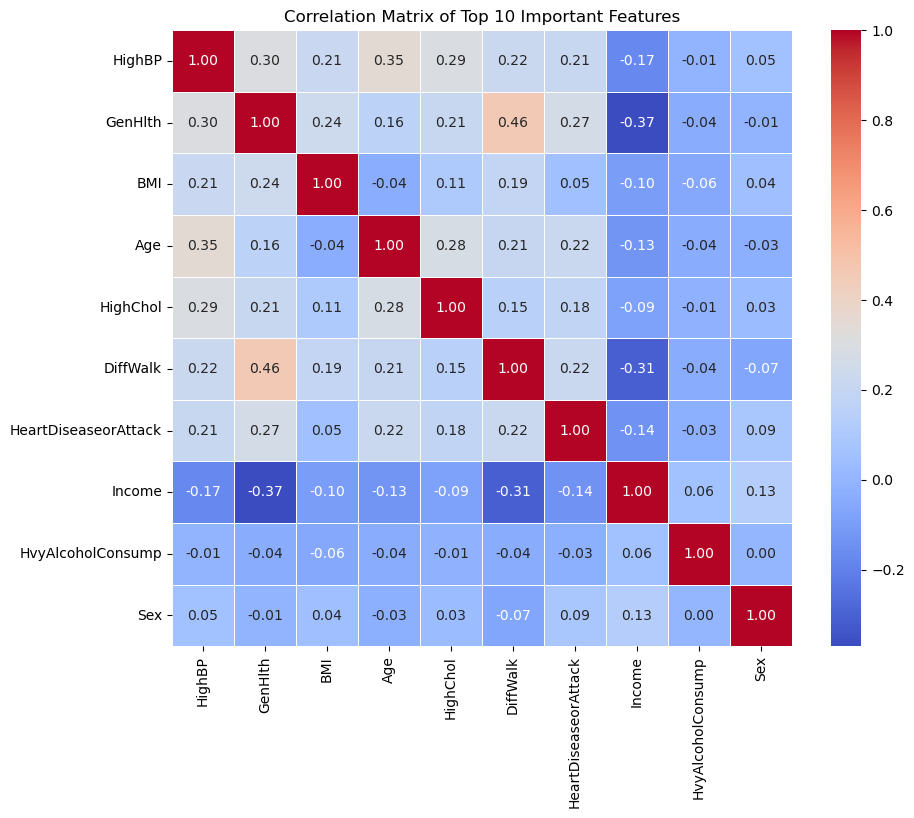

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# get top k features
top_features = feature_importance['Feature'].head(top_k).tolist()
df_top_features = X_test[top_features]

# calculate the correlation matrix
correlation_matrix = df_top_features.corr()

# plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Top 10 Important Features')
plt.show()


## Diabetes Risk by Age Group (Demographic Group)

C:\Users\Cecilia\AppData\Local\Temp\ipykernel_9804\3129053046.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_risk.index, y=age_risk.values, palette="coolwarm")


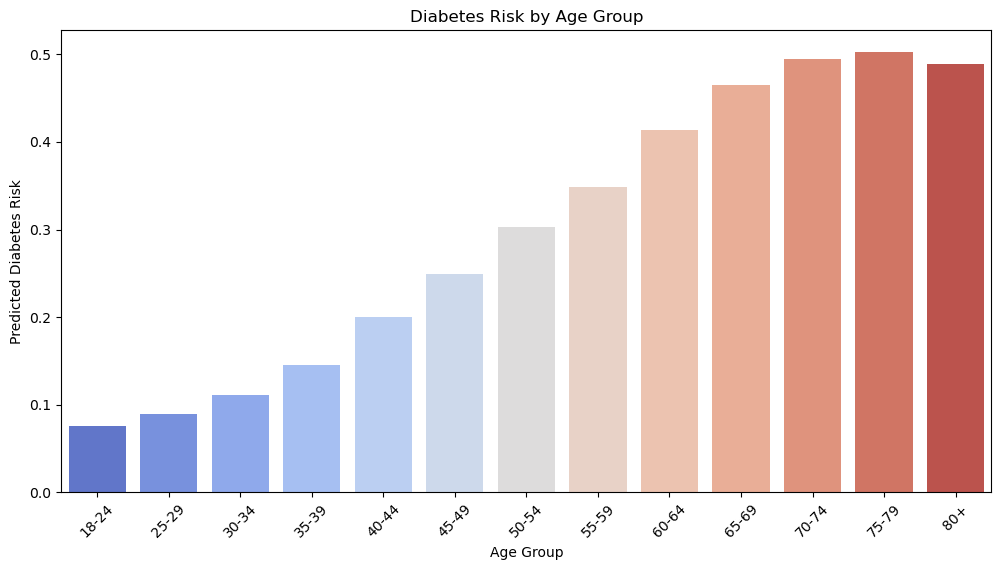

In [26]:
# use seaborn to plot the diabetes risk by age
age_labels = [
    '18-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
    '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+'
]

# change the age to age group
X_test['Age_Group'] = X_test['Age'].replace(dict(zip(range(1, 14), age_labels)))

# add the predicted diabetes risk to the DataFrame
X_test['Diabetes_Predicted'] = y_prob_gb_weighted

# calculate the average diabetes risk by age group
age_risk = X_test.groupby('Age_Group')['Diabetes_Predicted'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x=age_risk.index, y=age_risk.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Predicted Diabetes Risk")
plt.title("Diabetes Risk by Age Group")
plt.show()

## Feature Interaction

### Age and BMI Interaction on Diabetes Risk

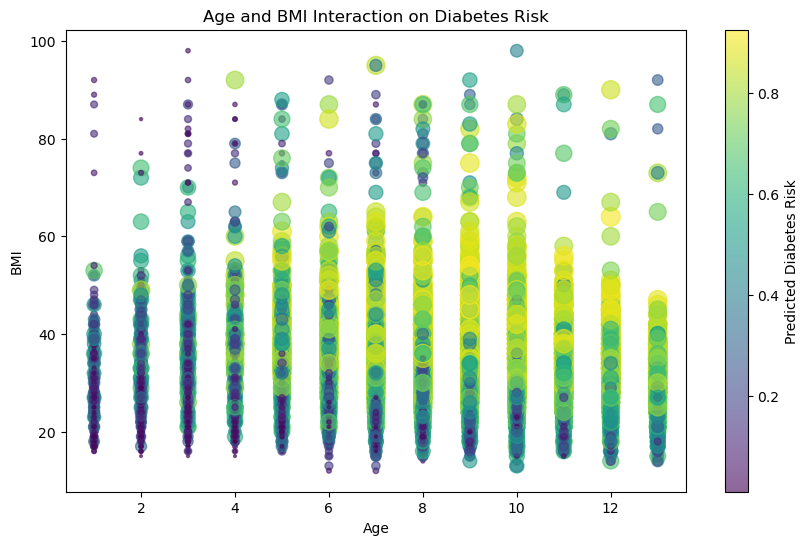

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# create a DataFrame with the relevant columns
df = pd.DataFrame({
    'Age': X_test['Age'],
    'BMI': X_test['BMI'],
    'HighBP': X_test['HighBP'],
    'DiabetesRisk': y_prob_gb_weighted
})

# Analyze the interaction between age and BMI on diabetes risk
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x=df['Age'], y=df['BMI'], c=df['DiabetesRisk'], s=df['DiabetesRisk']*200, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Predicted Diabetes Risk')
plt.title('Age and BMI Interaction on Diabetes Risk')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

### Age and HighBP Interaction on Diabetes Risk

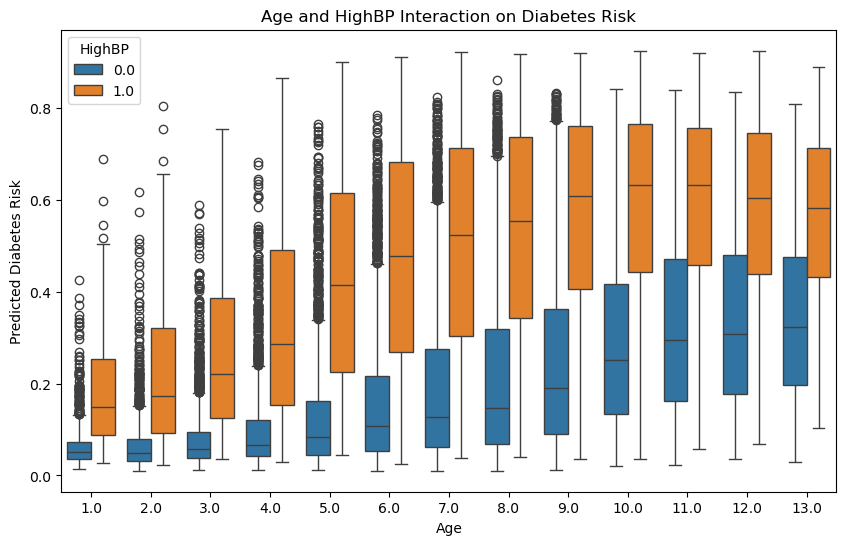

In [28]:
# Analyze the interaction between age, high blood pressure, and diabetes risk
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age', y='DiabetesRisk', hue='HighBP', data=df)
plt.title('Age and HighBP Interaction on Diabetes Risk')
plt.xlabel('Age')
plt.ylabel('Predicted Diabetes Risk')
plt.legend(title='HighBP')
plt.show()

# Create a new feature that captures the interaction between age and BMI
df['Age_BMI_Interaction'] = df['Age'] * df['BMI']

# Analyze the interaction between age, BMI, and diabetes risk

# Add interaction feature to training data
X_train_interaction = X_train.copy()
X_train_interaction['Age_BMI_Interaction'] = X_train['Age'] * X_train['BMI']

# Add interaction feature to test data
X_test_interaction = X_test.drop(columns=['Age_Group', 'Diabetes_Predicted']).copy()
X_test_interaction['Age_BMI_Interaction'] = X_test['Age'] * X_test['BMI']

# Fit the model with the interaction feature
gb_model_weighted_interaction = GradientBoostingClassifier(
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=3,  
    random_state=42
)

gb_model_weighted_interaction.fit(X_train_interaction, y_train, sample_weight=sample_weights)

# Make predictions with the interaction feature
y_prob_interaction = gb_model_weighted_interaction.predict_proba(X_test_interaction)[:, 1]



### Age and HighChol Interaction on Diabetes Risk

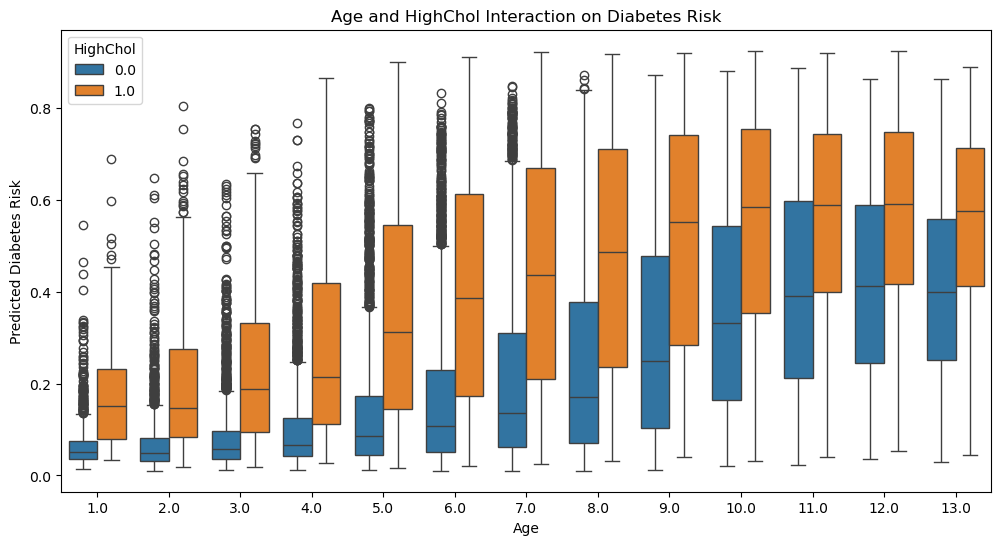

In [29]:
df = X_test.copy()
df['PredictedRisk'] = y_prob_gb_weighted
# age and high cholesterol interaction
age_highchol_risk = df.groupby(['Age', 'HighChol'])['PredictedRisk'].mean().unstack()
plt.figure(figsize=(12, 6))
sns.boxplot(x='Age', y='PredictedRisk', hue='HighChol', data=df)
plt.title('Age and HighChol Interaction on Diabetes Risk')
plt.xlabel('Age')
plt.ylabel('Predicted Diabetes Risk')
plt.legend(title='HighChol')
plt.show()

### GenHlth and DiffWalk Interaction on Diabetes Risk

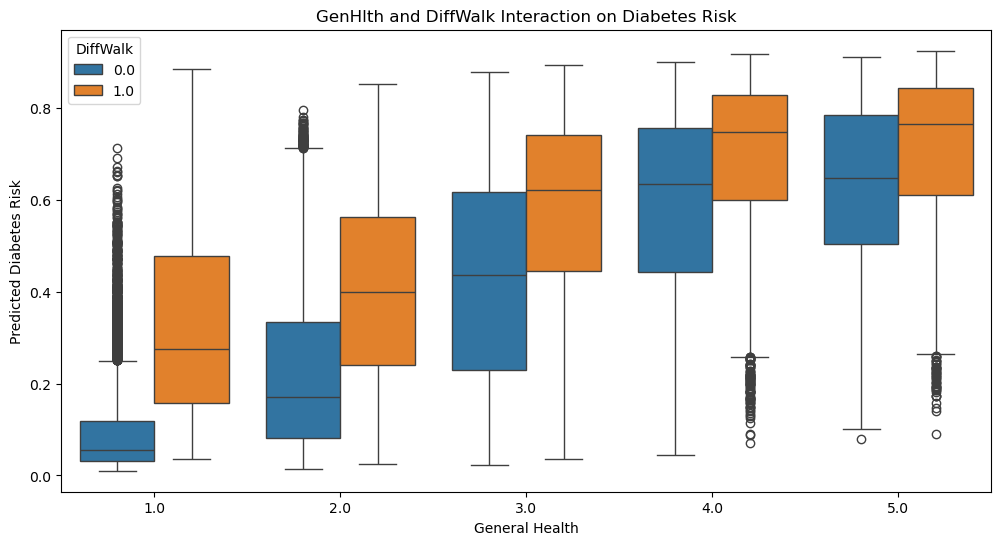

In [30]:
df = X_test.copy()
df['PredictedRisk'] = y_prob_gb_weighted

# genhlth and diffwalk interaction
genhlth_diffwalk_risk = df.groupby(['GenHlth', 'DiffWalk'])['PredictedRisk'].mean().unstack()


plt.figure(figsize=(12, 6))
sns.boxplot(x='GenHlth', y='PredictedRisk', hue='DiffWalk', data=df)
plt.title('GenHlth and DiffWalk Interaction on Diabetes Risk')
plt.xlabel('General Health')
plt.ylabel('Predicted Diabetes Risk')
plt.legend(title='DiffWalk')
plt.show()


### HighBP and HighChol Interaction on Diabetes Risk

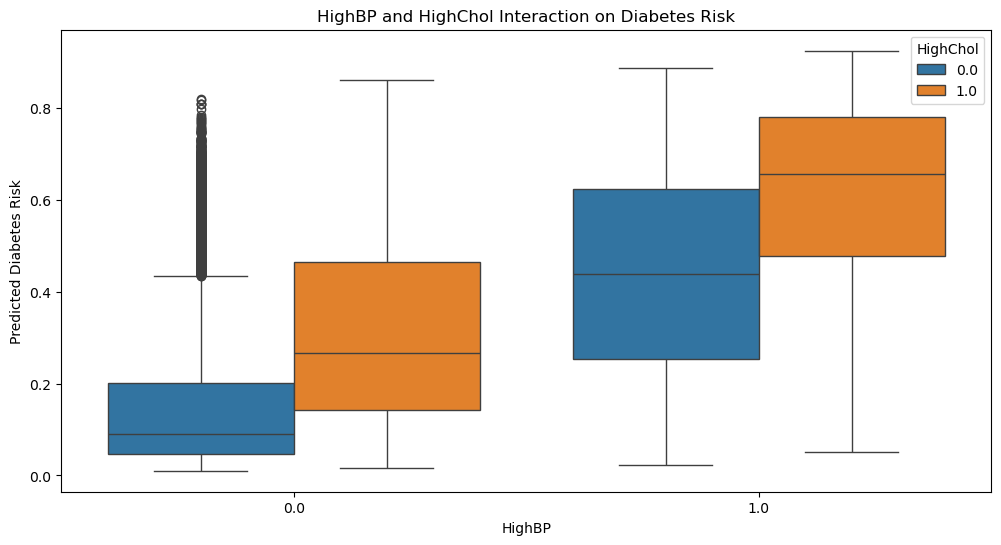

In [31]:
# high blood pressure and high cholesterol interaction
highbp_highchol_risk = df.groupby(['HighBP', 'HighChol'])['PredictedRisk'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.boxplot(x='HighBP', y='PredictedRisk', hue='HighChol', data=df)
plt.title('HighBP and HighChol Interaction on Diabetes Risk')
plt.xlabel('HighBP')
plt.ylabel('Predicted Diabetes Risk')
plt.legend(title='HighChol')
plt.show()

### GenHlth and DiffWalk Interaction on Diabetes Risk

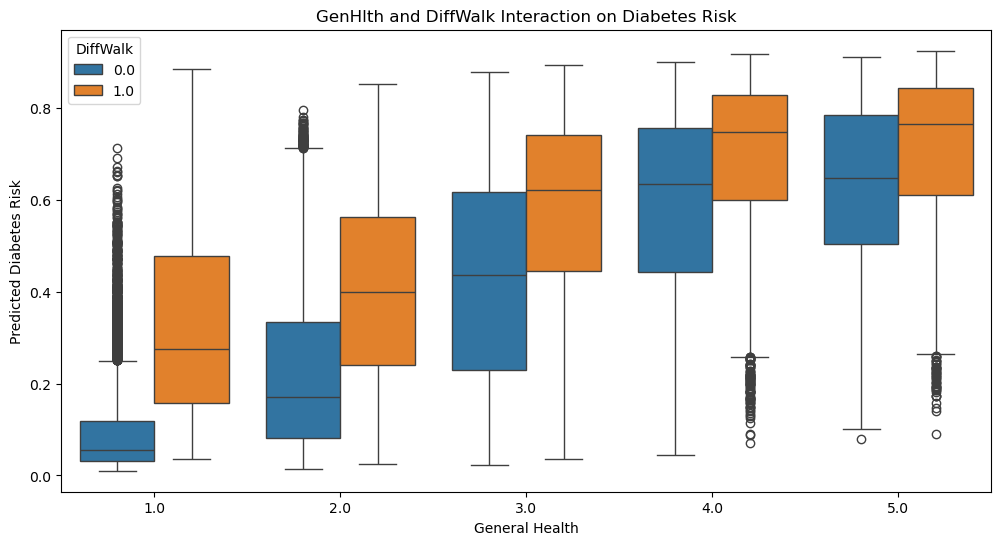

In [32]:
# genhlth and diffwalk interaction
genhlth_diffwalk_risk = df.groupby(['GenHlth', 'DiffWalk'])['PredictedRisk'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.boxplot(x='GenHlth', y='PredictedRisk', hue='DiffWalk', data=df)
plt.title('GenHlth and DiffWalk Interaction on Diabetes Risk')
plt.xlabel('General Health')
plt.ylabel('Predicted Diabetes Risk')
plt.legend(title='DiffWalk')
plt.show()

## 2. SHAP Value

c:\Users\Cecilia\anaconda3\envs\py39_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 99%|===================| 50230/50736 [00:47<00:00]        

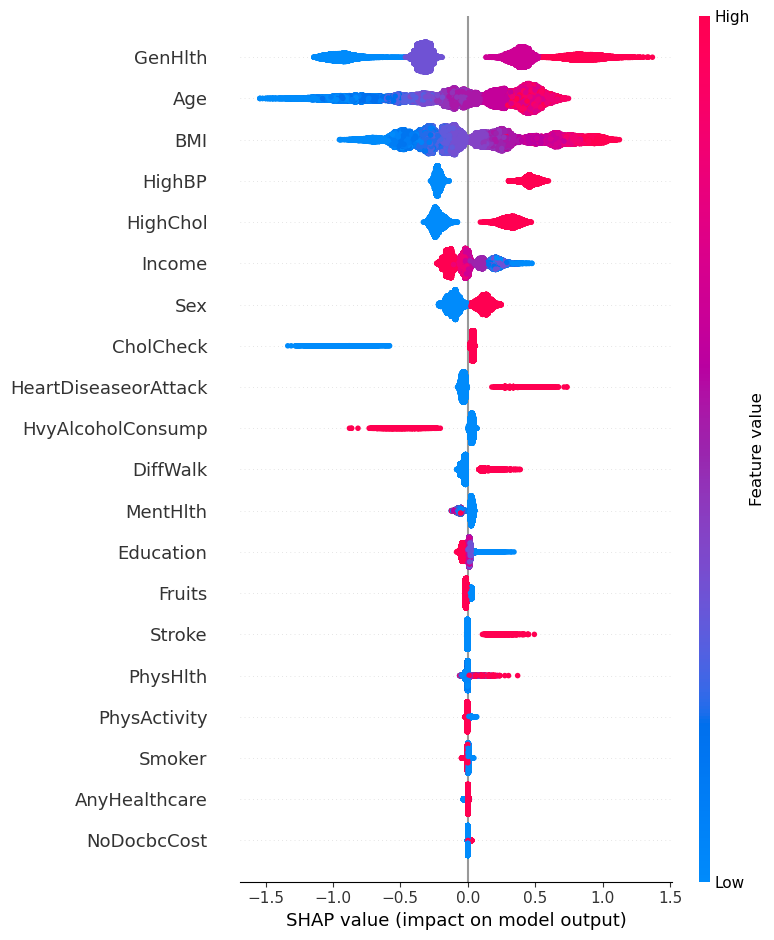

In [33]:
import shap
import matplotlib.pyplot as plt

# Drop non-numeric columns
X_test_numeric = X_test.drop(columns=['Age_Group', 'Diabetes_Predicted'])

# Ensure X_test is a numpy array with numeric dtype
X_test_numeric = X_test_numeric.astype(float)

# use the SHAP explainer to explain the model predictions
explainer = shap.Explainer(gb_model_weighted, X_test_numeric)

# calculate SHAP values
shap_values = explainer(X_test_numeric)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_numeric)

## SHAP Summary Plot


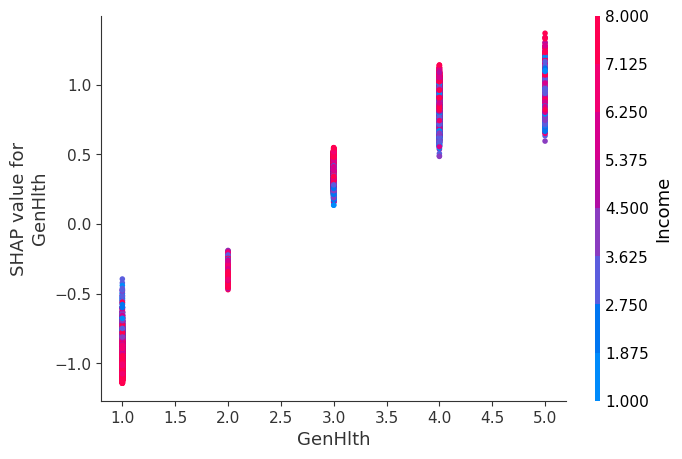

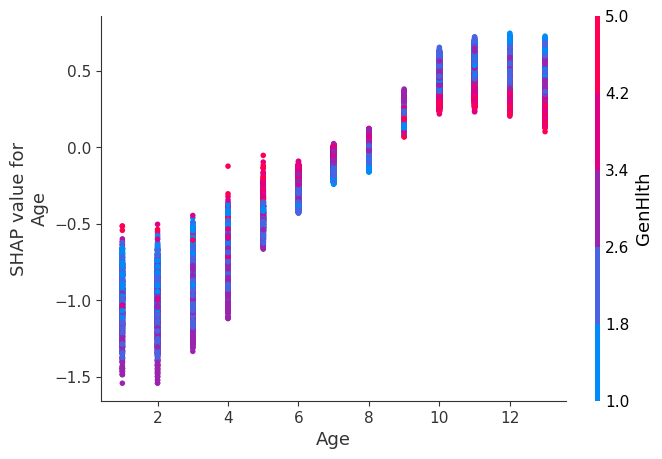

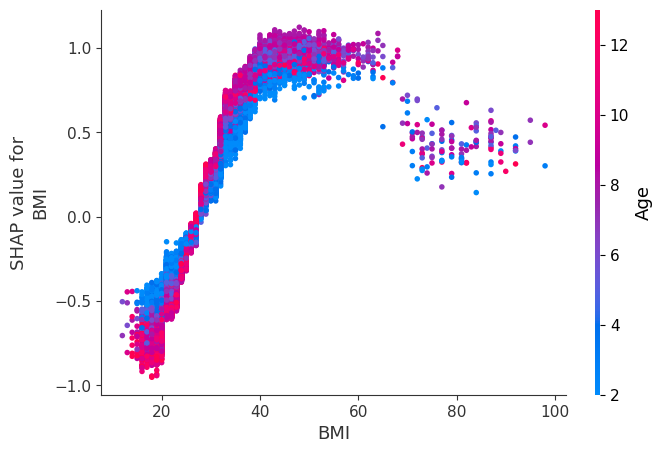

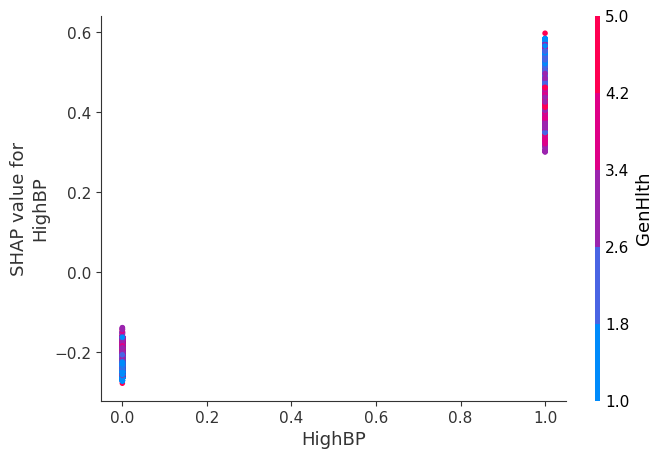

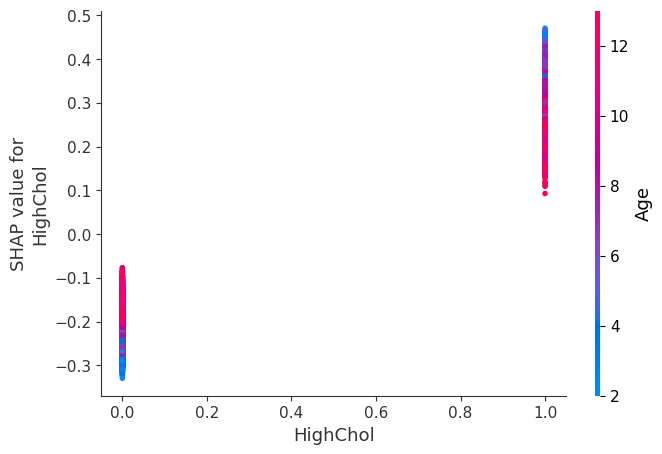

In [34]:
# Drop non-numeric columns from X_test
X_test_numeric = X_test.drop(columns=['Age_Group', 'Diabetes_Predicted'])

# Ensure X_test_numeric is a numpy array with numeric dtype
X_test_numeric = X_test_numeric.astype(float)

important_features = ['GenHlth', 'Age', 'BMI', 'HighBP', 'HighChol']
for feature in important_features:
    shap.dependence_plot(feature, shap_values.values, X_test_numeric)

# Conclusion:
Top 5 based on feature importance and SHAP: GenHlth, HighBP, BMI, Age, HighCho.